In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

import joblib

In [29]:
df = pd.read_csv("city_day.csv")


In [16]:
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01 00:00:00,258.0,340.6,191.0,13.4,104.1,16.2,1.15,39.8,70.4,11.64,10.23,1.95,411.5,Moderate
1,Mumbai,2015-01-01 00:00:00,120.1,47.9,165.3,57.9,139.2,14.4,0.76,3.3,23.2,11.35,11.38,1.53,134.8,Poor
2,Chennai,2015-01-01 00:00:00,130.1,375.0,21.9,23.7,205.6,33.6,3.50,63.0,138.9,16.30,24.07,0.56,329.6,Poor
3,Kolkata,2015-01-01 00:00:00,189.1,174.3,139.7,58.9,103.7,19.2,0.81,3.3,14.6,5.12,1.42,2.35,351.9,Good
4,Bangalore,2015-01-01 00:00:00,357.8,48.8,121.2,83.3,8.3,11.9,6.31,67.4,195.9,15.12,16.80,8.95,23.7,Moderate


In [30]:
df.shape

(18265, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  object 
 1   Datetime    18265 non-null  object 
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  object 
dtypes: float64(13), object(3)
memory usage: 2.2+ MB


In [32]:
df.columns

Index(['City', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO',
       'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')

In [ ]:
df.isnull().sum()

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [34]:
df.isna().sum().sort_values(ascending=False)

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [35]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


In [36]:
df["Datetime"] = pd.to_datetime(df["Datetime"], errors="coerce")
df = df.dropna(subset=["Datetime"])

df = df.sort_values(["City", "Datetime"]).reset_index(drop=True)

In [ ]:
city_name = "Delhi"
df_city = df[df["City"] == city_name].copy()
df_city = df_city.sort_values("Datetime").reset_index(drop=True)

df_city.shape

(3653, 16)

In [38]:
df_city = df_city.drop(columns=["AQI_Bucket"], errors="ignore")

In [39]:
df_city = df_city.drop(columns=["City"], errors="ignore")

In [40]:
pollutant_cols = [
    "PM2.5", "PM10", "NO", "NO2", "NOx",
    "NH3", "CO", "SO2", "O3", "Benzene",
    "Toluene", "Xylene"
]

In [41]:
lag_days = 7

for col in pollutant_cols:
    for lag in range(1, lag_days + 1):
        df_city[f"{col}_lag_{lag}"] = df_city[col].shift(lag)

In [42]:
df_city["day_of_week"] = df_city["Datetime"].dt.dayofweek
df_city["month"] = df_city["Datetime"].dt.month
df_city["day"] = df_city["Datetime"].dt.day 
#These help the model learn seasonal patterns.

In [43]:
df_city["target"] = df_city["AQI"].shift(-1)
#row at day t uses features from day t , target is AQI at day t+1

In [ ]:
df_city = df_city.dropna().reset_index(drop=True)

In [46]:
drop_cols = ["Datetime", "AQI", "target"]
X = df_city.drop(columns=drop_cols)
y = df_city["target"]
#Drop the columns you should not feed directly.

In [47]:
X.shape, y.shape

((3645, 99), (3645,))

In [48]:
split_index = int(len(df_city) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

In [49]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds = lr_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Linear Regression Performance")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2:.3f}")

Linear Regression Performance
MAE : 124.581
RMSE: 144.908
R2  : -0.035


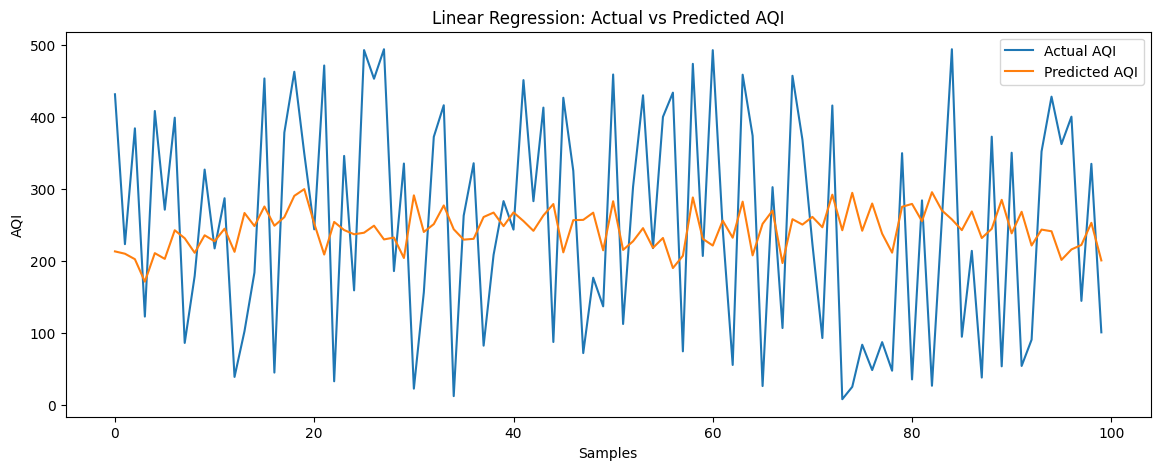

In [52]:
plt.figure(figsize=(14,5))
plt.plot(y_test.values[:100], label="Actual AQI")
plt.plot(preds[:100], label="Predicted AQI")

plt.title("Linear Regression: Actual vs Predicted AQI")
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.legend()
plt.show()

Plot Actual vs Predicted

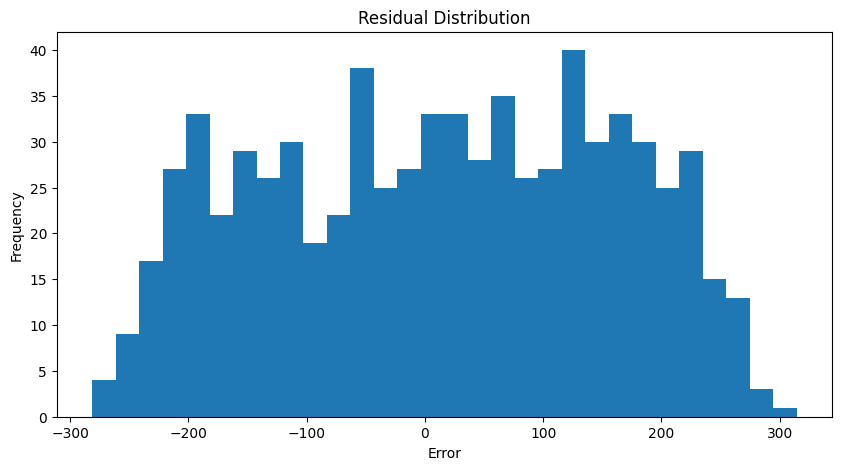

In [53]:
residuals = y_test.values - preds

plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [54]:
train_preds = lr_model.predict(X_train)

print("Train MAE:", mean_absolute_error(y_train, train_preds))
print("Test  MAE:", mean_absolute_error(y_test, preds))

Train MAE: 122.1570475985553
Test  MAE: 124.58092858630377


In [55]:
import joblib

joblib.dump(lr_model, "aqi_linear_model.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

['feature_columns.pkl']